# Monte Carlo Uncertainty Analysis (Hardened API)

This notebook demonstrates Monte Carlo uncertainty quantification for HEC-RAS hydraulic
models using the **hardened** `RasMonteCarlo` public API. The workflow generates parameter
samples from user-defined distributions, runs an ensemble of simulations via `RasPermutation`,
surfaces ensemble health, checks convergence, and computes percentile/prediction statistics
from the resulting HDF outputs.

## What You'll Learn

- Generate parameter samples with **Latin hypercube** (LHS) and **truncated-normal** methods
- Build an `apply_fn` with the shipped factory `RasMonteCarlo.make_mannings_apply_fn()` (no inline reimplementation)
- Run an ensemble and read its **status histogram** (`completed` / `completed_with_errors` / `failed`)
- Check Monte Carlo **convergence** with `RasMonteCarlo.convergence()` before trusting the statistics
- Compute full-domain percentiles with `exceedance_probabilities()` (with the default 95% valid-fraction guard)
- Compute a labelled **prediction (percentile) interval** with `prediction_intervals()`
- Compute point-level WSE risk with `risk_at_points()` and read its `status_accounting` attrs

## A Note On Sample Size (N=30)

Both examples use **N = 30**, a deliberately *modest, demonstration-scale* ensemble chosen so
the notebook runs in a tutorial timeframe. **Real flood-risk work needs far more** — the
repository research (`feature_dev_notes/Monte_Carlo_Uncertainty/research_findings.md` §9) calls
for roughly **500–1000 LHS samples** for robust percentile estimation, and tail percentiles
(P01/P99) are essentially meaningless at small N. N=30 here is large enough to *exercise the
hardened API honestly* (it is the minimum at which `prediction_intervals()` stops warning) but
is **not** a defensible production ensemble. The convergence diagnostic below reports whether
the chosen statistic has actually stabilized at N=30 — read it before trusting any band.

## Two Examples

| Example | Sampling method | Parameters varied | Output analysis |
|---------|----------------|-------------------|-----------------|
| 1 | Latin hypercube | Manning's n (2 land-cover classes) | Full-domain percentiles + convergence + prediction interval |
| 2 | Truncated normal | Manning's n (3 land-cover classes) | Point-level WSE risk statistics |

## Prerequisites

- HEC-RAS 6.x installed and resolvable by ras-commander
- `ras-commander` with the hardened `RasMonteCarlo` (this branch / ≥ the montecarlo-hardened release)
- **Expected runtime**: several hours (30 ensemble members each, 2D model, parallel workers)
- Disk space: cloned batch folders are created under the project; reuse logic skips completed runs

In [1]:
# !pip install ras-commander --quiet

### Dev Mode — Local Source Install

Uncomment the block in the next cell to load `ras-commander` from a local clone instead of the
installed package. Leave it commented when running from the published package. Never leave both
the pip-install cell and the dev-mode block active at the same time.

In [2]:
# Dev-mode toggle: uncomment to use a local ras-commander clone
# import sys, importlib
# sys.path.insert(0, r"G:/GH/ras-commander")
# import ras_commander
# importlib.reload(ras_commander)

In [3]:
from pathlib import Path
import sys

# Flexible imports for development vs installed package
try:
    from ras_commander import (
        init_ras_project, ras, RasExamples, RasPlan,
        RasMonteCarlo, RasPermutation,
    )
    from ras_commander.geom import GeomLandCover
    from ras_commander.hdf import HdfMesh
except ImportError:
    current_file = Path.cwd()
    parent_directory = current_file.parent
    sys.path.append(str(parent_directory))
    from ras_commander import (
        init_ras_project, ras, RasExamples, RasPlan,
        RasMonteCarlo, RasPermutation,
    )
    from ras_commander.geom import GeomLandCover
    from ras_commander.hdf import HdfMesh

import re
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("default")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

# ── Configuration ─────────────────────────────────────────────────────
PROJECT_NAME   = "BaldEagleCrkMulti2D"   # 2D unsteady example project
RAS_VERSION    = "6.6"                    # installed HEC-RAS version
TEMPLATE_PLAN  = "01"                     # plan used as the MC template
N_SAMPLES_EX1  = 30                       # Example 1 ensemble size (modest demo scale)
N_SAMPLES_EX2  = 30                       # Example 2 ensemble size (modest demo scale)
SEED           = 42                       # reproducible sampling
MAX_WORKERS    = 4                        # parallel HEC-RAS processes
NUM_CORES      = 2                        # cores per HEC-RAS process
TIMEOUT_SEC    = 86400                     # 24h per-plan cap (abandons hung 2D runs)

print(f"N_SAMPLES_EX1 = {N_SAMPLES_EX1}, N_SAMPLES_EX2 = {N_SAMPLES_EX2}")
print("Reminder: N=30 is demonstration scale; production flood-risk work needs ~500-1000 samples.")

N_SAMPLES_EX1 = 30, N_SAMPLES_EX2 = 30
Reminder: N=30 is demonstration scale; production flood-risk work needs ~500-1000 samples.


## Step 1 — Extract Project and Inspect Manning's n Table

We use `BaldEagleCrkMulti2D`, a 2D unsteady example bundled with ras-commander. Before defining
Monte Carlo parameters, we inspect the land-cover-based Manning's n table in the geometry file
so we know which class names are available to perturb. The class names matter: the shipped
`make_mannings_apply_fn()` factory matches sample columns to land-cover class names exactly.

In [4]:
# Extract a fresh copy so we don't pollute the cached example
project_path = RasExamples.extract_project(PROJECT_NAME, suffix="116mc")
init_ras_project(project_path, RAS_VERSION)

print(f"Project folder: {project_path}")
print(f"Plans in project: {len(ras.plan_df)}")
print()

plan_overview = ras.plan_df[["plan_number", "Plan Title", "geometry_number", "unsteady_number"]]
display(plan_overview.sort_values("plan_number").reset_index(drop=True))

# Confirm the template plan exists
assert TEMPLATE_PLAN in ras.plan_df["plan_number"].values, (
    f"Template plan {TEMPLATE_PLAN!r} not found.  Update TEMPLATE_PLAN above."
)

# Inspect the base Manning's n land-cover table from the geometry file
template_row  = ras.plan_df[ras.plan_df["plan_number"] == TEMPLATE_PLAN].iloc[0]
geom_path     = RasPlan.get_geom_path(template_row["geometry_number"])
mannings_base = GeomLandCover.get_base_mannings_n(geom_path)

if mannings_base.empty:
    raise RuntimeError(
        f"No 'LCMann Table' found in {Path(geom_path).name}.  "
        "Verify the geometry file uses land-cover-based Manning's n."
    )

# Drop any blank class names so the apply_fn always has a real class to target
mannings_named = mannings_base[
    mannings_base["Land Cover Name"].str.strip() != ""
].reset_index(drop=True)

print(f"\nManning's n land-cover classes in {Path(geom_path).name}: {len(mannings_named)}")
display(mannings_named)

Project folder: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_116mc
Plans in project: 11



,plan_number,Plan Title,geometry_number,unsteady_number
0,01,SA to Detailed 2D Breach FEQ,01,01
1,02,SA to Detailed 2D Breach,01,01
2,03,Single 2D Area - Internal Dam Structure,09,13
3,04,SA to 2D Area Conn - 2D Levee Structure,13,01
4,05,Single 2D area with Bridges FEQ,03,02
5,06,Gridded Precip - Infiltration,09,03
6,13,PMF with Multi 2D Areas,06,07
7,15,1d-2D Dambreak Refined Grid,08,12
8,17,2D to 1D No Dam,10,09
9,18,2D to 2D Run,11,10



Manning's n land-cover classes in BaldEagleDamBrk.g01: 16


,Table Number,Land Cover Name,Base Mannings n Value
0,17,NoData,0.060
1,17,Barren Land Rock/Sand/Clay,0.040
2,17,Cultivated Crops,0.060
3,17,Deciduous Forest,0.100
4,17,"Developed, High Intensity",0.150
5,17,"Developed, Low Intensity",0.100
6,17,"Developed, Medium Intensity",0.080
7,17,"Developed, Open Space",0.040
8,17,Emergent Herbaceous Wetlands,0.080
9,17,Evergreen Forest,0.120


## Helper — Reuse Completed Ensemble Results

Ensemble runs are expensive, so each example reuses completed result HDFs when they already
exist on disk (idempotent re-runs). The helper below reconstructs an ensemble-result dict whose
shape matches `RasMonteCarlo.run_ensemble()` output: a `results_df` with a `status` column, plus
`completed` / `completed_with_errors` / `failed` counts and a `status_histogram`. The hardened
statistics methods read these fields, so the reuse stub must populate them honestly.

In [5]:
_PLAN_HDF_RE = re.compile(r"\.p\d{2,3}\.hdf$", re.IGNORECASE)


def discover_completed_hdfs(project_folder, suffix):
    """Return sorted plan-result HDFs across all batch folders for a suffix."""
    batches = list(RasPermutation.discover_batch_folders(project_folder, suffix=suffix))
    hdfs = sorted(
        h
        for b in batches
        for h in Path(b).rglob("*.hdf")
        if _PLAN_HDF_RE.search(h.name) and not h.name.endswith(".tmp.hdf")
    )
    return batches, hdfs


def build_reuse_ensemble(hdf_paths, n_samples):
    """Reconstruct a run_ensemble()-shaped dict from completed HDFs.

    All reused samples are treated as ``completed`` (they produced a plan HDF
    and were retained on disk). The returned dict carries the status counts and
    histogram that the hardened statistics / convergence methods expect.
    """
    rows = [
        {
            "sample_id": float(i + 1),
            "status": "completed",
            "hdf_path": str(h),
            "runtime_seconds": None,
        }
        for i, h in enumerate(hdf_paths[:n_samples])
    ]
    results_df = pd.DataFrame(rows)
    return {
        "total_samples": n_samples,
        "completed": len(rows),
        "completed_with_errors": 0,
        "failed": 0,
        "status_histogram": {"total": len(rows), "completed": len(rows)},
        "results_df": results_df,
    }


def report_ensemble_health(ensemble_result, label):
    """Surface the hardened ensemble-health accounting (C2 / M1)."""
    histogram = RasMonteCarlo.status_histogram(ensemble_result)
    print(f"{label} ensemble health")
    print(f"  total samples         : {ensemble_result.get('total_samples')}")
    print(f"  completed             : {ensemble_result.get('completed')}")
    print(f"  completed_with_errors : {ensemble_result.get('completed_with_errors')}")
    print(f"  failed                : {ensemble_result.get('failed')}")
    print(f"  status_histogram      : {histogram}")
    cwe = ensemble_result.get("completed_with_errors", 0) or 0
    if cwe:
        print(
            f"  NOTE: {cwe} run(s) finished with compute errors and are "
            "EXCLUDED from statistics by default (include_error_runs=False)."
        )
    return histogram


print("Reuse / health helpers defined.")

Reuse / health helpers defined.


## Example 1 — Latin Hypercube Manning's n Sweep

Latin hypercube sampling (LHS) partitions each parameter's range into equal-probability strata
and draws one sample per stratum, giving better parameter-space coverage than random sampling at
the same N. We vary Manning's n for **two land-cover classes** and tag each spec with
`kind="mannings_n"` so the hardened sampler emits a physical-range warning (H3) if any bound
leaves the plausible roughness range ~[0.01, 0.2].

Workflow: `generate_samples` → `make_mannings_apply_fn` → `run_ensemble` → `status_histogram`
→ `convergence` → `exceedance_probabilities` → `prediction_intervals`.

Classes selected for Example 1:
  'NoData'                                  base n = 0.0600
  'Barren Land Rock/Sand/Clay'              base n = 0.0400

Generated 30 samples (Latin hypercube):


,sample_id,NoData,Barren Land Rock/Sand/Clay
0,1,0.05490,0.03709
1,2,0.05228,0.04280
2,3,0.05103,0.04073
3,4,0.05628,0.04896
4,5,0.06110,0.04433
5,6,0.05721,0.04196
6,7,0.07574,0.03963
7,8,0.06979,0.04595
8,9,0.06311,0.03920
9,10,0.04798,0.04319


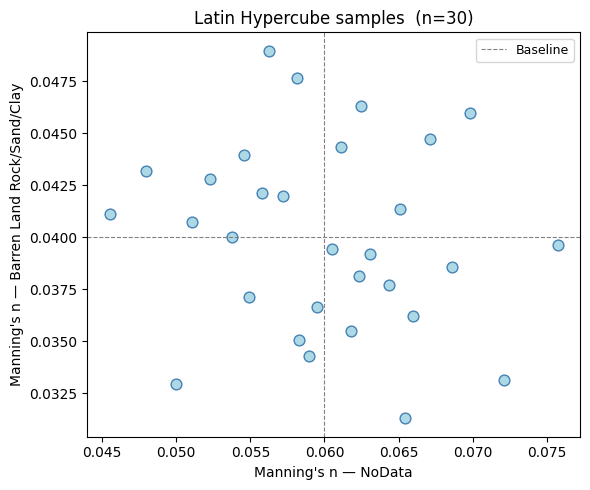

In [6]:
# Pick two land-cover classes to perturb
lc_rows  = mannings_named.iloc[:2]
lc_names = lc_rows["Land Cover Name"].tolist()
lc_base  = lc_rows["Base Mannings n Value"].tolist()

print("Classes selected for Example 1:")
for name, base in zip(lc_names, lc_base):
    print(f"  {name!r:40s}  base n = {base:.4f}")

# param_specs: column name == land-cover class name (the apply_fn maps by name).
# kind="mannings_n" enables the hardened physical-range bounds warning (H3).
param_specs_ex1 = {
    lc_names[0]: {
        "min":  lc_base[0] * 0.70,
        "max":  lc_base[0] * 1.30,
        "mean": lc_base[0],
        "std":  lc_base[0] * 0.12,
        "kind": "mannings_n",
    },
    lc_names[1]: {
        "min":  lc_base[1] * 0.70,
        "max":  lc_base[1] * 1.30,
        "mean": lc_base[1],
        "std":  lc_base[1] * 0.12,
        "kind": "mannings_n",
    },
}

samples_ex1 = RasMonteCarlo.generate_samples(
    param_specs = param_specs_ex1,
    n_samples   = N_SAMPLES_EX1,
    method      = "latin_hypercube",
    seed        = SEED,
)

print(f"\nGenerated {len(samples_ex1)} samples (Latin hypercube):")
display(samples_ex1.head(10).round(5))

# Visualise parameter coverage
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    samples_ex1[lc_names[0]], samples_ex1[lc_names[1]],
    s=60, edgecolors="steelblue", facecolors="lightblue",
)
ax.axvline(lc_base[0], color="grey", linestyle="--", linewidth=0.8, label="Baseline")
ax.axhline(lc_base[1], color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel(f"Manning's n — {lc_names[0]}")
ax.set_ylabel(f"Manning's n — {lc_names[1]}")
ax.set_title(f"Latin Hypercube samples  (n={N_SAMPLES_EX1})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
# Build the apply_fn from the SHIPPED FACTORY (L1) instead of an inline reimplementation.
# zone_column_map maps each land-cover class name -> the sample column carrying its n value.
# Here the column names already equal the class names, so the map is identity.
apply_fn_ex1 = RasMonteCarlo.make_mannings_apply_fn(
    zone_column_map = {name: name for name in lc_names},
    path            = "plaintext",   # perturb the plain-text base LCMann table
)

# Smart reuse: skip re-running if completed result HDFs already exist
_ex1_batches, _ex1_done_hdfs = discover_completed_hdfs(project_path, suffix="mc_ex1")

if len(_ex1_done_hdfs) >= N_SAMPLES_EX1:
    print(f"Found {len(_ex1_done_hdfs)} completed result HDFs — reusing (skipping re-run).")
    ensemble_ex1 = build_reuse_ensemble(_ex1_done_hdfs, N_SAMPLES_EX1)
else:
    if _ex1_batches:
        print(f"Removing {len(_ex1_batches)} incomplete batch folder(s)...")
        for folder in _ex1_batches:
            shutil.rmtree(folder, ignore_errors=True)

    ensemble_ex1 = RasMonteCarlo.run_ensemble(
        template_plan = TEMPLATE_PLAN,
        samples_df    = samples_ex1,
        apply_fn      = apply_fn_ex1,
        suffix        = "mc_ex1",
        max_workers   = MAX_WORKERS,
        num_cores     = NUM_CORES,
        timeout_sec   = TIMEOUT_SEC,
    )

# C2 / M1: surface full ensemble health before computing any statistics
report_ensemble_health(ensemble_ex1, "Example 1")
display(ensemble_ex1["results_df"][["sample_id", "status"]].head(10))

Example 1 ensemble health
  total samples         : 30
  completed             : 30
  completed_with_errors : 0
  failed                : 0
  status_histogram      : {'total': 30, 'completed': 30}


,sample_id,status
0,1.0,completed
1,2.0,completed
2,3.0,completed
3,4.0,completed
4,5.0,completed
5,6.0,completed
6,7.0,completed
7,8.0,completed
8,9.0,completed
9,10.0,completed


### Convergence Diagnostic (C3)

Before reporting any percentile band we ask whether the statistic has *stabilized* at this N.
`RasMonteCarlo.convergence()` recomputes a running statistic (here the domain-aggregated P90 WSE)
over the first `k` samples for `k = 1..N` and flags `stabilized=True` when the maximum relative
change across the trailing `window` samples falls below `tolerance` (2% here). At N=30 the result
is reported honestly — if `stabilized` is `False`, the bands below are **not** trustworthy and a
production run would need many more samples.

Convergence statistic        : p90 (aggregate mean)
Samples used                 : 30
Stabilization window / tol   : 5 samples / 2%
Final relative change        : 0.0000
Stabilized at N=30? : True
  -> Running P90 has stabilized within tolerance at this N (still a small ensemble).


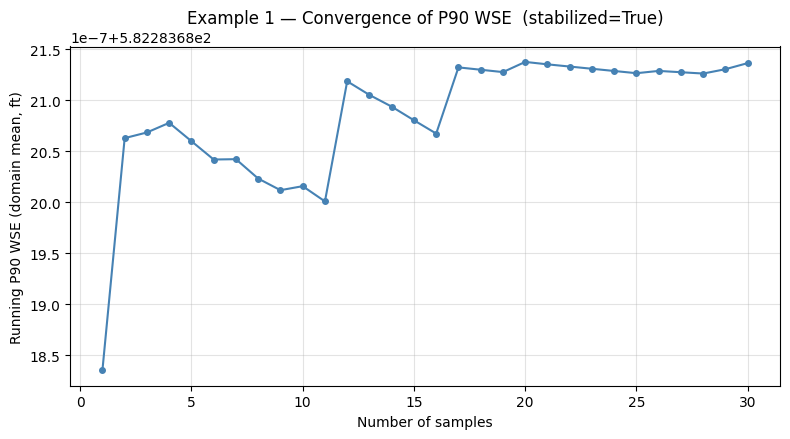

In [8]:
conv_ex1 = RasMonteCarlo.convergence(
    ensemble_result = ensemble_ex1,
    variable        = "wse",
    statistic       = "p90",
    window          = 5,
    tolerance       = 0.02,
    aggregate       = "mean",   # reduce per-cell P90 to one scalar per sample count
)

sample_counts     = np.asarray(conv_ex1["sample_counts"])
running_statistic = np.asarray(conv_ex1["running_statistic"])
stabilized        = conv_ex1["stabilized"]
final_rel_change  = conv_ex1["final_relative_change"]

print(f"Convergence statistic        : {conv_ex1['statistic']} (aggregate mean)")
print(f"Samples used                 : {conv_ex1['n_samples_used']}")
print(f"Stabilization window / tol   : {conv_ex1['window']} samples / {conv_ex1['tolerance']:.0%}")
print(f"Final relative change        : {final_rel_change:.4f}")
print(f"Stabilized at N={N_SAMPLES_EX1}? : {stabilized}")
if stabilized:
    print("  -> Running P90 has stabilized within tolerance at this N (still a small ensemble).")
else:
    print("  -> NOT stabilized: the P90 band below is demonstration-only; add samples for production.")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sample_counts, running_statistic, marker="o", markersize=4, color="steelblue")
ax.set_xlabel("Number of samples")
ax.set_ylabel("Running P90 WSE (domain mean, ft)")
ax.set_title(f"Example 1 — Convergence of P90 WSE  (stabilized={stabilized})")
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

Samples used in aggregation : 30 (of 30)
Status accounting           : {'total_samples': 30, 'n_samples_used': 30, 'valid_fraction': 1.0, 'dropped_missing_hdf': [], 'dropped_extraction_error': [], 'status_histogram': {'total': 30, 'completed': 30}, 'include_error_runs': False}
Wet cells                   : 89,879
Mean WSE range              : 0.00 - 911.60 ft
P90 - P10 band  (median)    : 0.0000 ft
Percentiles are NON-EXCEEDANCE quantiles (value not exceeded N% of the time across samples).


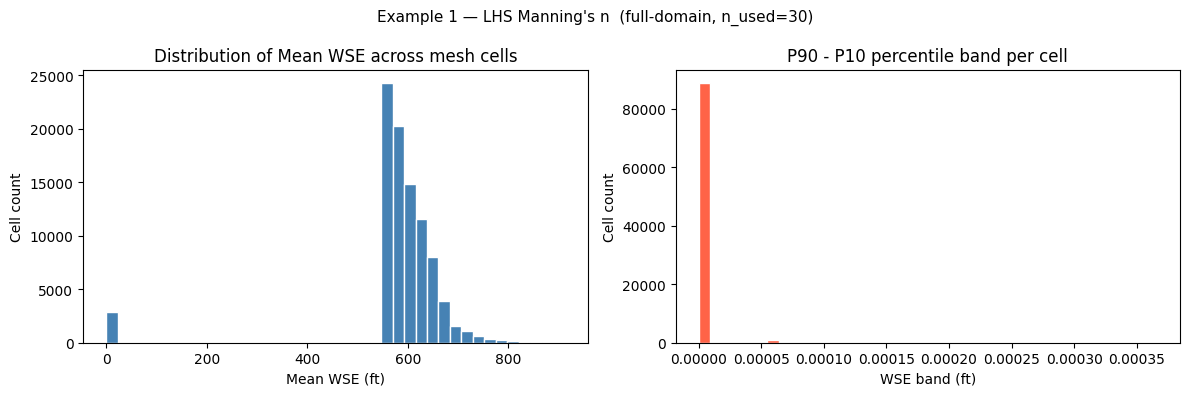

In [9]:
# Full-domain percentiles. The default min_valid_fraction=0.95 guard (C2) raises if too many
# samples were dropped/failed; we rely on it rather than overriding allow_low_valid_fraction.
exc_ex1 = RasMonteCarlo.exceedance_probabilities(
    ensemble_result = ensemble_ex1,
    variable        = "wse",
    percentiles     = [90, 50, 10],
)

n_used   = exc_ex1["n_samples_used"]
mean_wse = exc_ex1["mean"]
p90_wse  = exc_ex1["percentiles"][90.0]
p50_wse  = exc_ex1["percentiles"][50.0]
p10_wse  = exc_ex1["percentiles"][10.0]

# Mask dry cells (NaN) for plotting
wet    = ~np.isnan(mean_wse)
spread = p90_wse[wet] - p10_wse[wet]    # percentile band per cell

print(f"Samples used in aggregation : {n_used} (of {ensemble_ex1['total_samples']})")
print(f"Status accounting           : {exc_ex1['status_accounting']}")
print(f"Wet cells                   : {wet.sum():,}")
print(f"Mean WSE range              : {mean_wse[wet].min():.2f} - {mean_wse[wet].max():.2f} ft")
print(f"P90 - P10 band  (median)    : {np.nanmedian(spread):.4f} ft")
print("Percentiles are NON-EXCEEDANCE quantiles (value not exceeded N% of the time across samples).")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(mean_wse[wet], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Mean WSE across mesh cells")
axes[0].set_xlabel("Mean WSE (ft)")
axes[0].set_ylabel("Cell count")

axes[1].hist(spread, bins=40, color="tomato", edgecolor="white")
axes[1].set_title("P90 - P10 percentile band per cell")
axes[1].set_xlabel("WSE band (ft)")
axes[1].set_ylabel("Cell count")

plt.suptitle(f"Example 1 — LHS Manning's n  (full-domain, n_used={n_used})", fontsize=11)
plt.tight_layout()
plt.show()

### Prediction (Percentile) Interval (M3)

`prediction_intervals()` returns the central `confidence_level` band of the realized variable.
Despite the legacy `confidence_intervals` name, this is a **prediction / percentile interval on
the variable**, NOT a confidence interval on a statistic — the returned `interval_type` is
`"prediction"`. We label it accordingly and report `n_samples_used`. At N=30 the method stops
warning (its `min_samples_warn` default is 30), but the band is still demonstration-scale.

Interval type        : prediction  (prediction/percentile, NOT a CI on a statistic)
Confidence level     : 90%
Lower/upper pctile   : 5.0 / 95.0
Samples used         : 30
Median band width    : 0.0000 ft (90% prediction band per cell)


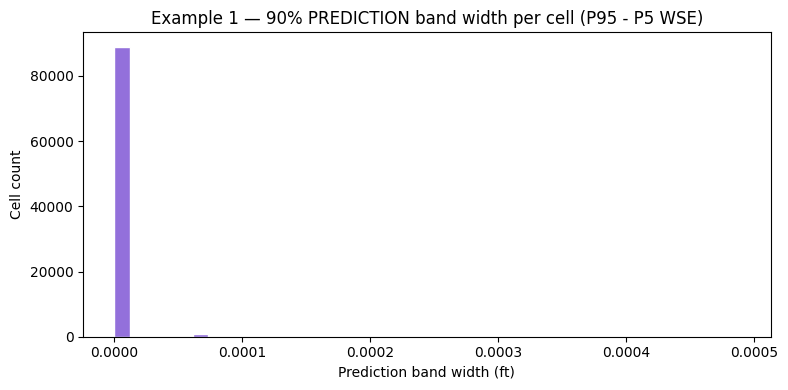

In [10]:
pred_ex1 = RasMonteCarlo.prediction_intervals(
    ensemble_result  = ensemble_ex1,
    variable         = "wse",
    confidence_level = 0.90,   # central 90% band -> 5th/50th/95th percentiles
)

lower_band = pred_ex1["lower"]
upper_band = pred_ex1["upper"]
wet_pi     = ~np.isnan(lower_band) & ~np.isnan(upper_band)
band_width = upper_band[wet_pi] - lower_band[wet_pi]

print(f"Interval type        : {pred_ex1['interval_type']}  (prediction/percentile, NOT a CI on a statistic)")
print(f"Confidence level     : {pred_ex1['confidence_level']:.0%}")
print(f"Lower/upper pctile   : {pred_ex1['lower_percentile']:.1f} / {pred_ex1['upper_percentile']:.1f}")
print(f"Samples used         : {pred_ex1['n_samples_used']}")
print(f"Median band width    : {np.nanmedian(band_width):.4f} ft (90% prediction band per cell)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(band_width, bins=40, color="mediumpurple", edgecolor="white")
ax.set_title("Example 1 — 90% PREDICTION band width per cell (P95 - P5 WSE)")
ax.set_xlabel("Prediction band width (ft)")
ax.set_ylabel("Cell count")
plt.tight_layout()
plt.show()

## Example 2 — Truncated Normal + Point-Level Risk

The truncated normal concentrates samples near a calibrated baseline while respecting physical
min/max bounds — ideal for local sensitivity around a well-characterised prior. We vary **three
land-cover classes**, again building the apply_fn from the shipped factory, then compute WSE risk
statistics at a handful of mesh-cell locations with `risk_at_points()`. The point-level output is
a compact DataFrame alternative to the full-domain arrays from `exceedance_probabilities()`, and
carries the same bias accounting via `df.attrs`.

Classes selected for Example 2:
  'NoData'                                  base n = 0.0600
  'Barren Land Rock/Sand/Clay'              base n = 0.0400
  'Cultivated Crops'                        base n = 0.0600

Generated 30 samples (truncated normal):


,sample_id,NoData,Barren Land Rock/Sand/Clay,Cultivated Crops
0,1,0.06622,0.04363,0.06361
1,2,0.05872,0.04992,0.05940
2,3,0.06886,0.03751,0.06136
3,4,0.06428,0.03817,0.06598
4,5,0.04920,0.03958,0.06286
5,6,0.07576,0.03515,0.06112
6,7,0.06588,0.03381,0.06124
7,8,0.06656,0.03966,0.05575
8,9,0.05065,0.03587,0.04496
9,10,0.05897,0.04243,0.05868


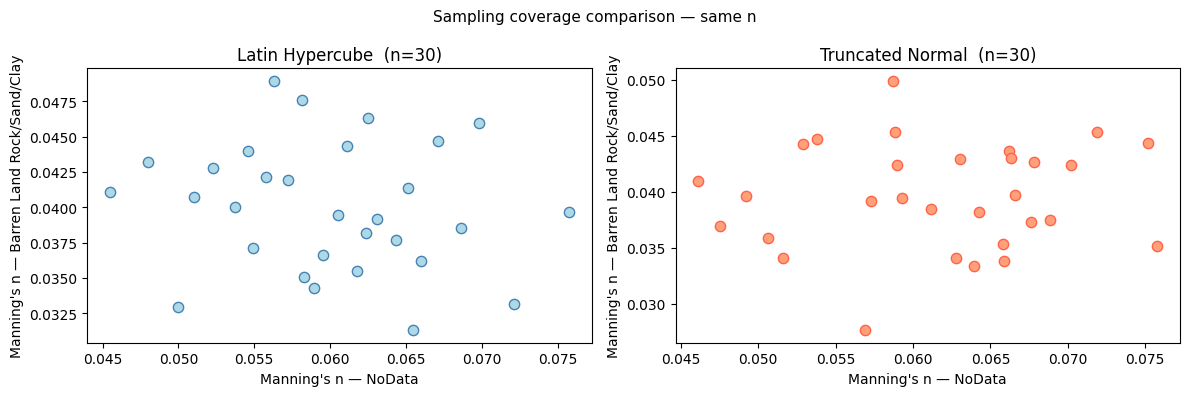

In [11]:
# Three land-cover classes (rows 0, 1, 2 of the named table)
lc_rows3  = mannings_named.iloc[:3]
lc_names3 = lc_rows3["Land Cover Name"].tolist()
lc_base3  = lc_rows3["Base Mannings n Value"].tolist()

print("Classes selected for Example 2:")
for name, base in zip(lc_names3, lc_base3):
    print(f"  {name!r:40s}  base n = {base:.4f}")

param_specs_ex2 = {
    name: {
        "min":  base * 0.65,
        "max":  base * 1.35,
        "mean": base,
        "std":  base * 0.14,
        "kind": "mannings_n",
    }
    for name, base in zip(lc_names3, lc_base3)
}

samples_ex2 = RasMonteCarlo.generate_samples(
    param_specs = param_specs_ex2,
    n_samples   = N_SAMPLES_EX2,
    method      = "truncated_normal",
    seed        = SEED,
)

print(f"\nGenerated {len(samples_ex2)} samples (truncated normal):")
display(samples_ex2.head(10).round(5))

# Compare coverage: LHS (Ex1) vs truncated normal (Ex2) for the first two parameters
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(
    samples_ex1[lc_names[0]], samples_ex1[lc_names[1]],
    s=55, edgecolors="steelblue", facecolors="lightblue",
)
axes[0].set_title(f"Latin Hypercube  (n={N_SAMPLES_EX1})")
axes[0].set_xlabel(f"Manning's n — {lc_names[0]}")
axes[0].set_ylabel(f"Manning's n — {lc_names[1]}")

axes[1].scatter(
    samples_ex2[lc_names3[0]], samples_ex2[lc_names3[1]],
    s=55, edgecolors="tomato", facecolors="lightsalmon",
)
axes[1].set_title(f"Truncated Normal  (n={N_SAMPLES_EX2})")
axes[1].set_xlabel(f"Manning's n — {lc_names3[0]}")
axes[1].set_ylabel(f"Manning's n — {lc_names3[1]}")

plt.suptitle("Sampling coverage comparison — same n", fontsize=11)
plt.tight_layout()
plt.show()

In [12]:
# Build the Example 2 apply_fn from the shipped factory (3 classes)
apply_fn_ex2 = RasMonteCarlo.make_mannings_apply_fn(
    zone_column_map = {name: name for name in lc_names3},
    path            = "plaintext",
)

# Smart reuse for Example 2
_ex2_batches, _ex2_done_hdfs = discover_completed_hdfs(project_path, suffix="mc_ex2")

if len(_ex2_done_hdfs) >= N_SAMPLES_EX2:
    print(f"Found {len(_ex2_done_hdfs)} completed result HDFs — reusing (skipping re-run).")
    ensemble_ex2 = build_reuse_ensemble(_ex2_done_hdfs, N_SAMPLES_EX2)
else:
    if _ex2_batches:
        print(f"Removing {len(_ex2_batches)} incomplete batch folder(s)...")
        for folder in _ex2_batches:
            shutil.rmtree(folder, ignore_errors=True)

    ensemble_ex2 = RasMonteCarlo.run_ensemble(
        template_plan = TEMPLATE_PLAN,
        samples_df    = samples_ex2,
        apply_fn      = apply_fn_ex2,
        suffix        = "mc_ex2",
        max_workers   = MAX_WORKERS,
        num_cores     = NUM_CORES,
        timeout_sec   = TIMEOUT_SEC,
    )

report_ensemble_health(ensemble_ex2, "Example 2")

Example 2 ensemble health
  total samples         : 30
  completed             : 30
  completed_with_errors : 0
  failed                : 0
  status_histogram      : {'total': 30, 'completed': 30}


{'total': 30, 'completed': 30}

Mesh cells available: 89,879
Points of interest (x, y):
  POI-0: (2083700.00, 370900.00)
  POI-1: (2075100.00, 356600.00)
  POI-2: (2039300.00, 346000.00)
  POI-3: (2016600.00, 333100.00)



n_samples_used (attrs)  : 30
status_accounting (attrs): {'total_samples': 30, 'n_samples_used': 30, 'valid_fraction': 1.0, 'dropped_missing_hdf': [], 'dropped_extraction_error': [], 'status_histogram': {'total': 30, 'completed': 30}, 'include_error_runs': False}

Point-level risk summary:


,point_index,x,y,n_samples,mean,std,p10,p50,p90
0,0,2083700.0,370900.0,30,669.267,0.0,669.267,669.267,669.267
1,1,2075100.0,356600.0,30,663.023,0.0,663.023,663.023,663.023
2,2,2039300.0,346000.0,30,596.752,0.0,596.752,596.752,596.752
3,3,2016600.0,333100.0,30,657.403,0.0,657.403,657.403,657.403


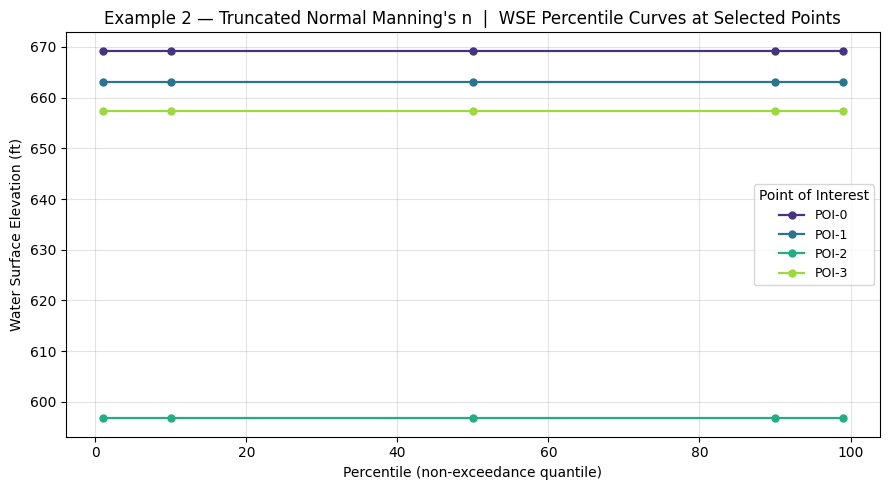

In [13]:
# Derive representative mesh-cell coordinates for point-level risk analysis.
cells_gdf = HdfMesh.get_mesh_cell_points(TEMPLATE_PLAN, ras_object=ras)

# Sample 4 cells evenly spaced by index to span the domain
n_cells = len(cells_gdf)
step    = max(1, n_cells // 4)
poi_idx = list(range(0, n_cells, step))[:4]
poi_pts = [
    (cells_gdf.geometry.iloc[i].x, cells_gdf.geometry.iloc[i].y)
    for i in poi_idx
]

print(f"Mesh cells available: {n_cells:,}")
print("Points of interest (x, y):")
for j, (x, y) in enumerate(poi_pts):
    print(f"  POI-{j}: ({x:.2f}, {y:.2f})")

# Point-level WSE statistics across completed ensemble members.
# Default min_valid_fraction=0.95 guard applies; status accounting is attached via df.attrs.
risk_df = RasMonteCarlo.risk_at_points(
    ensemble_result = ensemble_ex2,
    points          = poi_pts,
    variable        = "wse",
)

print(f"\nn_samples_used (attrs)  : {risk_df.attrs.get('n_samples_used')}")
print(f"status_accounting (attrs): {risk_df.attrs.get('status_accounting')}")
print("\nPoint-level risk summary:")
display(
    risk_df[["point_index", "x", "y", "n_samples",
             "mean", "std", "p10", "p50", "p90"]].round(3)
)

# Plot WSE percentile curves at each point
fig, ax = plt.subplots(figsize=(9, 5))
pct_cols = ["p01", "p10", "p50", "p90", "p99"]
pct_vals = [1, 10, 50, 90, 99]
colors   = plt.cm.viridis(np.linspace(0.15, 0.85, len(risk_df)))

for (_, row), c in zip(risk_df.iterrows(), colors):
    wse_pcts = [row[col] for col in pct_cols]
    ax.plot(
        pct_vals, wse_pcts,
        marker="o", markersize=5, linewidth=1.6,
        color=c, label=f"POI-{int(row['point_index'])}",
    )

ax.set_xlabel("Percentile (non-exceedance quantile)")
ax.set_ylabel("Water Surface Elevation (ft)")
ax.set_title("Example 2 — Truncated Normal Manning's n  |  WSE Percentile Curves at Selected Points")
ax.legend(title="Point of Interest", fontsize=9)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

## Summary

| | Example 1 | Example 2 |
|---|---|---|
| **Sampling method** | Latin hypercube | Truncated normal |
| **Parameters** | 2 land-cover Manning's n | 3 land-cover Manning's n |
| **Ensemble size** | 30 (`N_SAMPLES_EX1`) | 30 (`N_SAMPLES_EX2`) |
| **apply_fn source** | `make_mannings_apply_fn()` (shipped factory) | `make_mannings_apply_fn()` (shipped factory) |
| **Ensemble health** | `status_histogram()` printed | `status_histogram()` printed |
| **Convergence** | `convergence(p90)` — see `stabilized` flag printed above | (shared diagnostic) |
| **Result analysis** | `exceedance_probabilities()` + `prediction_intervals()` | `risk_at_points()` |

### Hardened-API Methods Exercised

1. `RasMonteCarlo.generate_samples(...)` — LHS and truncated-normal, single threaded `default_rng` (H5), `kind="mannings_n"` bounds warning (H3)
2. `RasMonteCarlo.make_mannings_apply_fn(...)` — shipped factory exercised instead of an inline apply_fn (L1)
3. `RasMonteCarlo.run_ensemble(...)` — returns `completed` / `completed_with_errors` / `failed` + `status_histogram` (M1)
4. `RasMonteCarlo.status_histogram(...)` — surfaces ensemble health before statistics (C2)
5. `RasMonteCarlo.convergence(...)` — running P90 stabilization check (C3)
6. `RasMonteCarlo.exceedance_probabilities(...)` — default 0.95 valid-fraction guard, `status_accounting` reported (C2)
7. `RasMonteCarlo.prediction_intervals(...)` — labelled `interval_type="prediction"`, `n_samples_used` reported (M3)
8. `RasMonteCarlo.risk_at_points(...)` — point statistics with `n_samples_used` / `status_accounting` in `df.attrs` (C2)

### Limitations — Not Defensible At This N

- **N=30 is demonstration scale, not production.** Robust percentile estimation needs ~500–1000 LHS
  samples (research §9). Tail percentiles (P01/P99) and the 90% prediction band reported here are
  dominated by sampling error at N=30; treat them as illustrative only.
- **Trust the convergence flag.** The Example 1 cell prints whether the running P90 actually
  `stabilized` at N=30. If `False`, the bands are not yet trustworthy — increase the sample count.
- **Independent per-class sampling.** Manning's n classes are sampled independently (no correlation
  structure), which can overstate spatial uncertainty relative to correlated-zone calibration error.
- **Percentiles are non-exceedance quantiles** (value not exceeded N% of the time across samples),
  not annual exceedance probabilities, and mix aleatory + epistemic uncertainty in one ensemble.
- **Error runs are excluded by default.** Runs with status `completed_with_errors` are dropped from
  statistics unless `include_error_runs=True`; the dropped fraction biases the tail and is reported
  via the status histogram / `status_accounting`.
- **Flow-multiplier note (H2):** `make_flow_multiplier_apply_fn` (not used here) writes
  `Flow Hydrograph QMult=`, a UNIFORM ordinate multiplier scaling peak AND volume together — it is
  NOT an AEP / flow-frequency sample. This notebook perturbs Manning's n only.
- **Sensitivity analysis (Morris/Sobol) is out of scope** in this version of `RasMonteCarlo`.